# Kosmiczne zagrożenie: Ocena ryzyka obiektów bliskich Ziemi (NEO)

### **Kontekst i cel projektu:**
Zbiór danych *Neo* opisuje obiekty w pobliżu Ziemi zidentyfikowane przez NASA. Cel to określenie, czy obiekt stanowi zagrożenie dla naszej planety.


### **Kryteria sukcesu:**
Zatrzymać koniec świata najmniejszym kosztem:
* **Wynik fałszywie negatywny (FN):** Zignorowanie ryzyka oznacza porażkę i katastrofę dla planety (kluczowe do wyeliminowania).
* **Wynik fałszywie pozytywny (FP):** Fałszywy alarm to zmarnowane miliardy dolarów i przeciążenie agencji astronomicznych.

## 1. Importy potrzebnych do roziwązania problemu bibliotek

In [32]:
import pandas as pd
import seaborn as sns
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#from now on pile shall grow
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from imblearn.over_sampling import SMOTE


## 2. Wczytanie danych
Pobranie zbioru danyhc do DataFrame i wstępna analiza danych wyświetlenie rozmiaru, opis kolumn, typy danych.

#### 2.1. Słownik danych i typy zmiennych

| **Nazwa kolumny** | **Typ danych** | **Opis i znaczenie danych** |
| :---: | :---: | :--- |
| **id** | `float64 / int64` | Unikalny identyfikator każdej asteroidy |
| **name** | `object (string)` | Nazwa nadana obiektowi przez NASA |
| **est_diameter_min** | `float64` | Minimalna szacowana średnica obiektu (w km) |
| **est_diameter_max** | `float64` | Maksymalna szacowana średnica obiektu (w km) |
| **relative_velocity** | `float64` | Prędkość obiektu względem Ziemi |
| **miss_distance** | `float64` | Odległość, o jaką obiekt minął Ziemię (w km) |
| **orbiting_body** | `object (string)` | Ciało niebieskie, wokół którego krąży obiekt (Ziemia) |
| **sentry_object** | `bool / object` | Czy obiekt jest w systemie automatycznego monitoringu Sentry |
| **absolute_magnitude**| `float64` | Jasność absolutna (miara blasku obiektu) |
| **hazardous** | `bool` | **Zmienna docelowa:** Czy obiekt stanowi zagrożenie? |

---

#### 2.2 Szczególowy opis danych
Przedstawienie podstawowego rozkladdu danych, wyswietlenie kilku pierwszych wierszy oraz wyświetlenia struktury danych

In [7]:
# Wczytanie danych
file_path = 'neo.csv'
df = pd.read_csv(file_path)


# Nazwy kolumn i typy
print(" ---------- STRUKTURA KOLUMN ---------- ")
print(df.dtypes)
print("-" * 30)

print("\n ----------  INFO ----------  ")
df.info()

# Opis kolum, rozklad
print("\n ----------  STATYSTYKI OPISOWE ----------  ")
display(df.describe())

# Podglad
print("\n ----------  PIERWSZE WIERSZE ----------  ")
display(df.head())



 ---------- STRUKTURA KOLUMN ---------- 
id                      int64
name                   object
est_diameter_min      float64
est_diameter_max      float64
relative_velocity     float64
miss_distance         float64
orbiting_body          object
sentry_object            bool
absolute_magnitude    float64
hazardous                bool
dtype: object
------------------------------

 ----------  INFO ----------  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 n

,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,9.083600e+04,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,1.438288e+07,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,2.087202e+07,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,2.000433e+06,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,3.448110e+06,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,3.748362e+06,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,3.884023e+06,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,5.427591e+07,37.892650,84.730541,236990.128088,7.479865e+07,33.200000



 ----------  PIERWSZE WIERSZE ----------  


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


## 3. Sprawdzenie danych
Znalezienie wartości odstajacych, braków w danych, znalezienie duplikatów

In [8]:
#Braki
print("----- MISSING DATA -----")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.any() else "Wszystko jest")
print()

#Duplitakty
print("----- DUPLICATES -----")
duplicates_count = df.duplicated().sum()
print(f"Liczba zduplikowanych wierszy: {duplicates_count}")
print()

#Wartosci odstajace
print("----- OUTLIERS -----")
numeric_features = ['est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    mid_range = Q3 - Q1
    lower_bound = Q1 - 1.5 * mid_range
    upper_bound = Q3 + 1.5 * mid_range

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: znaleziono {len(outliers)} outlierów (zakres: {lower_bound:.2f} - {upper_bound:.2f})")



----- MISSING DATA -----
Wszystko jest

----- DUPLICATES -----
Liczba zduplikowanych wierszy: 0

----- OUTLIERS -----
est_diameter_max: znaleziono 8306 outlierów (zakres: -0.37 - 0.74)
relative_velocity: znaleziono 1574 outlierów (zakres: -22837.86 - 114380.48)
miss_distance: znaleziono 0 outlierów (zakres: -41796444.09 - 115556260.77)
absolute_magnitude: znaleziono 101 outlierów (zakres: 14.80 - 32.24)


## 4. Wizualizacja danych
Sprawdzenie czy zbiór jest zbalansowany, wyświetlenie macierzy koralcja i sprawdznie jak dane od siebie zalezą.

#### 4.1. Przygotowanie danych do analizy (Encoding)

Aby uwzględnić zmienne logiczne w macierzy korelacji, True/False -> 1/0.

In [9]:
df_analysis = df.copy()


df_analysis['hazardous'] = df_analysis['hazardous'].astype(int)
#df_analysis['sentry_object'] = df_analysis['sentry_object'].astype(int)

print(df_analysis[['hazardous', 'sentry_object']].dtypes)


hazardous        int64
sentry_object     bool
dtype: object


#### 4.2 Sprawdznie balansu klas
Sprzwdzam czy klasy są rozłozone dobrze czy model moze ignorowac klase bo jest jej mało.

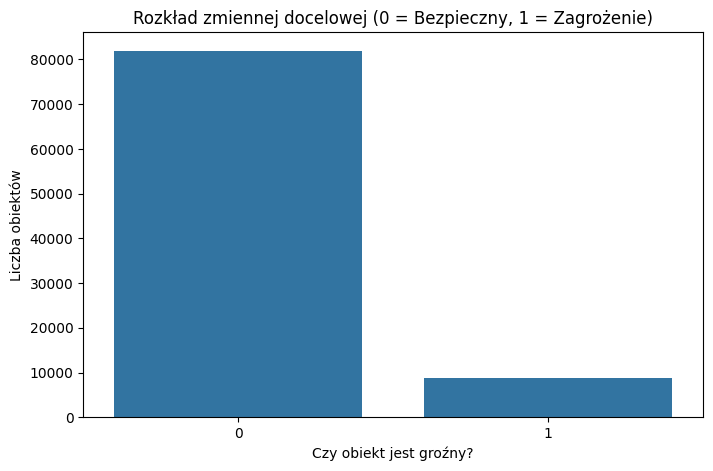

Procentowy udział klas:
hazardous
0    90.268176
1     9.731824
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(x='hazardous', data=df_analysis)
plt.title('Rozkład zmiennej docelowej (0 = Bezpieczny, 1 = Zagrożenie)')
plt.xlabel('Czy obiekt jest groźny?')
plt.ylabel('Liczba obiektów')
plt.show()

# Procentowy udział
print("Procentowy udział klas:")
print(df_analysis['hazardous'].value_counts(normalize=True) * 100)

#### 4.3 Macierz korelacji
Sprawdzenie które cechy na siebie wpływaja.

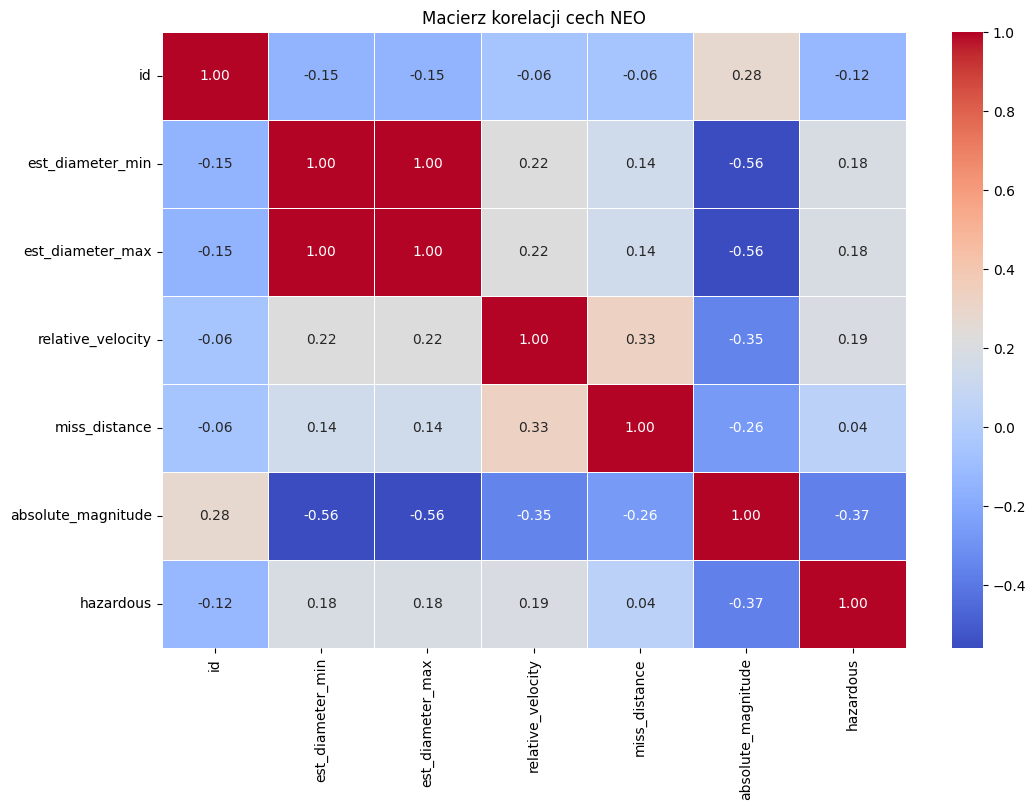

In [11]:
cols_to_corr = df_analysis.select_dtypes(include=['number']).columns
corr_matrix = df_analysis[cols_to_corr].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji cech NEO')
plt.show()

#### 4.4 Analiza zalerzności
Wizualizacja jak dane na siebie wpływwją.

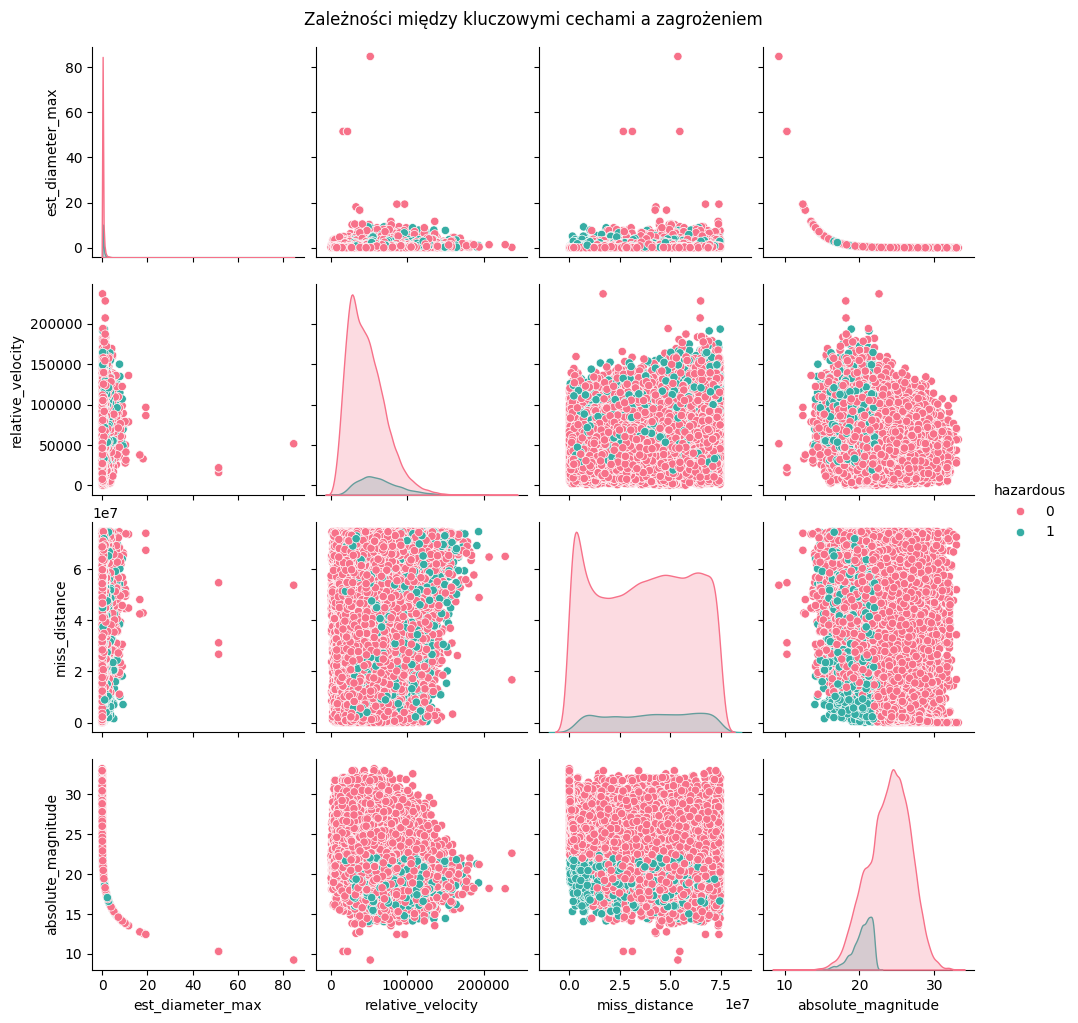

In [12]:
features_to_plot = ['est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous']

sns.pairplot(df_analysis[features_to_plot], hue='hazardous', palette='husl', diag_kind='kde')
plt.suptitle('Zależności między kluczowymi cechami a zagrożeniem', y=1.02)
plt.show()

## 5. Dodatkowe wykresy szczegółowe
Wykesry pokazujące czy są jakieś anomalie w danych i inne bardziej szczegolowe wykresy.

#### 5.1 Wykresy anomalii
Wykresy przedstawiajace jak rozkladaja sie dane pokazujace odchylwania oraz anamailie w danych (box plot)

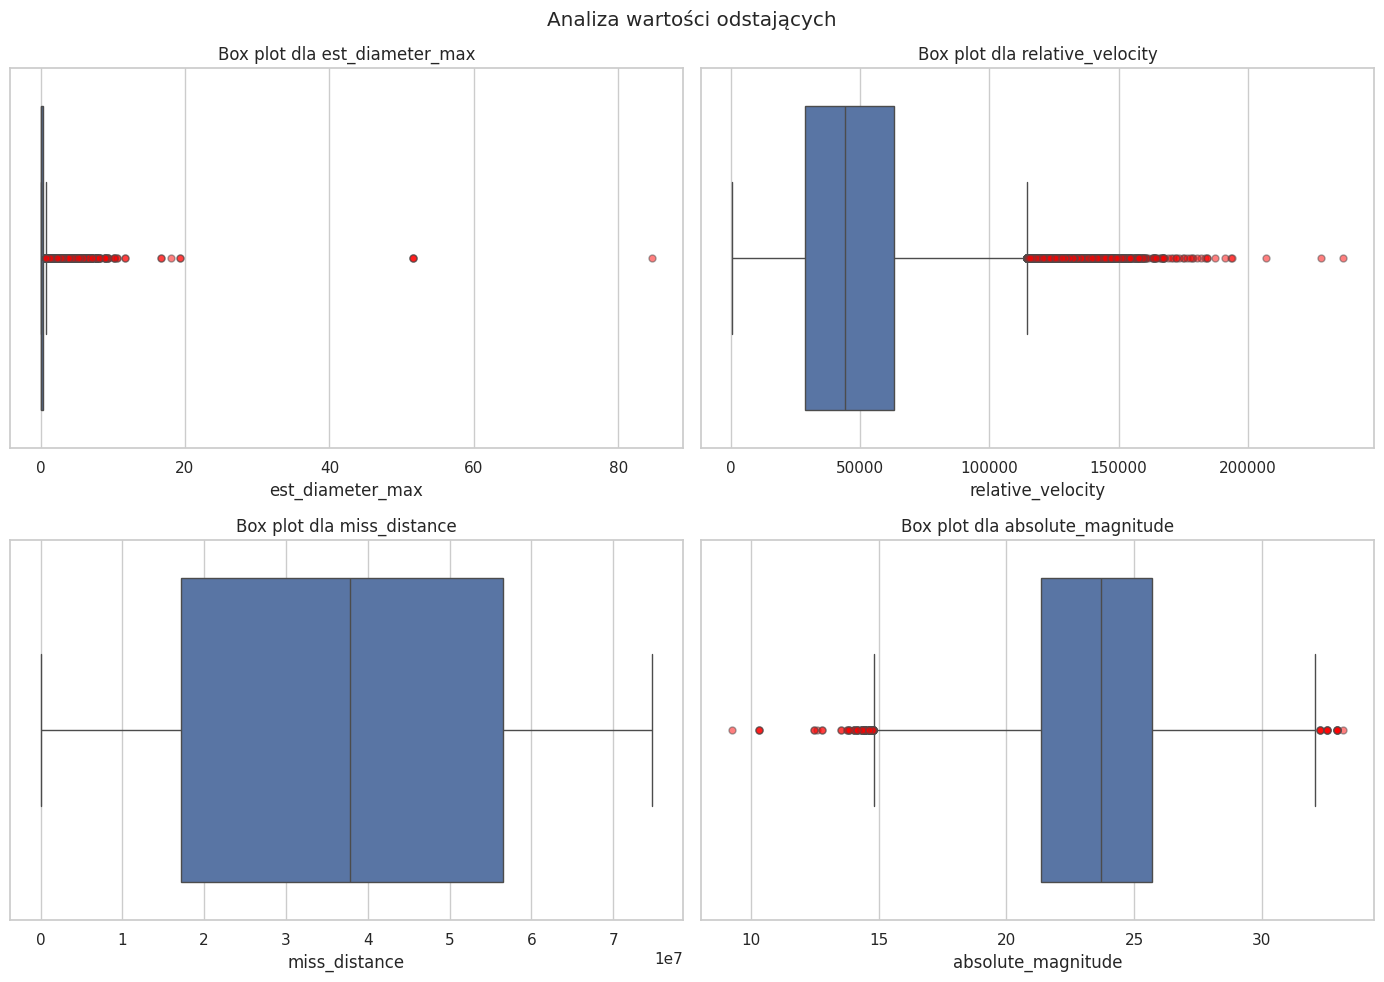

In [ ]:
feats_to_plot = ['est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2,2, figsize=(14, 10))
fig.suptitle("Analiza wartości odstających")
for ax, feat in zip(axes.flatten(), feats_to_plot):
  sns.boxplot(
      x=df_analysis[feat],
      ax=ax,
      flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5)
  )
  ax.set_title(f"Box plot dla {feat}")

plt.tight_layout()
plt.show()

Jak wspomniano wcześniej `miss_distamce` ma najszerszy regularny rozkład i jako jedyna z głównych zmiennych nie posiada wartości odstających.

Zmienne `est_diameter_max` i `relative_velocity` posiadają szczególne prawostronne ogony, zaś w przypadku `absolute_magnitude` widoczne są pojedyncze anomalie po obu stronach rozkładu.

#### 5.2 Szczegolowe wykresy
Wykresy wiolinowe

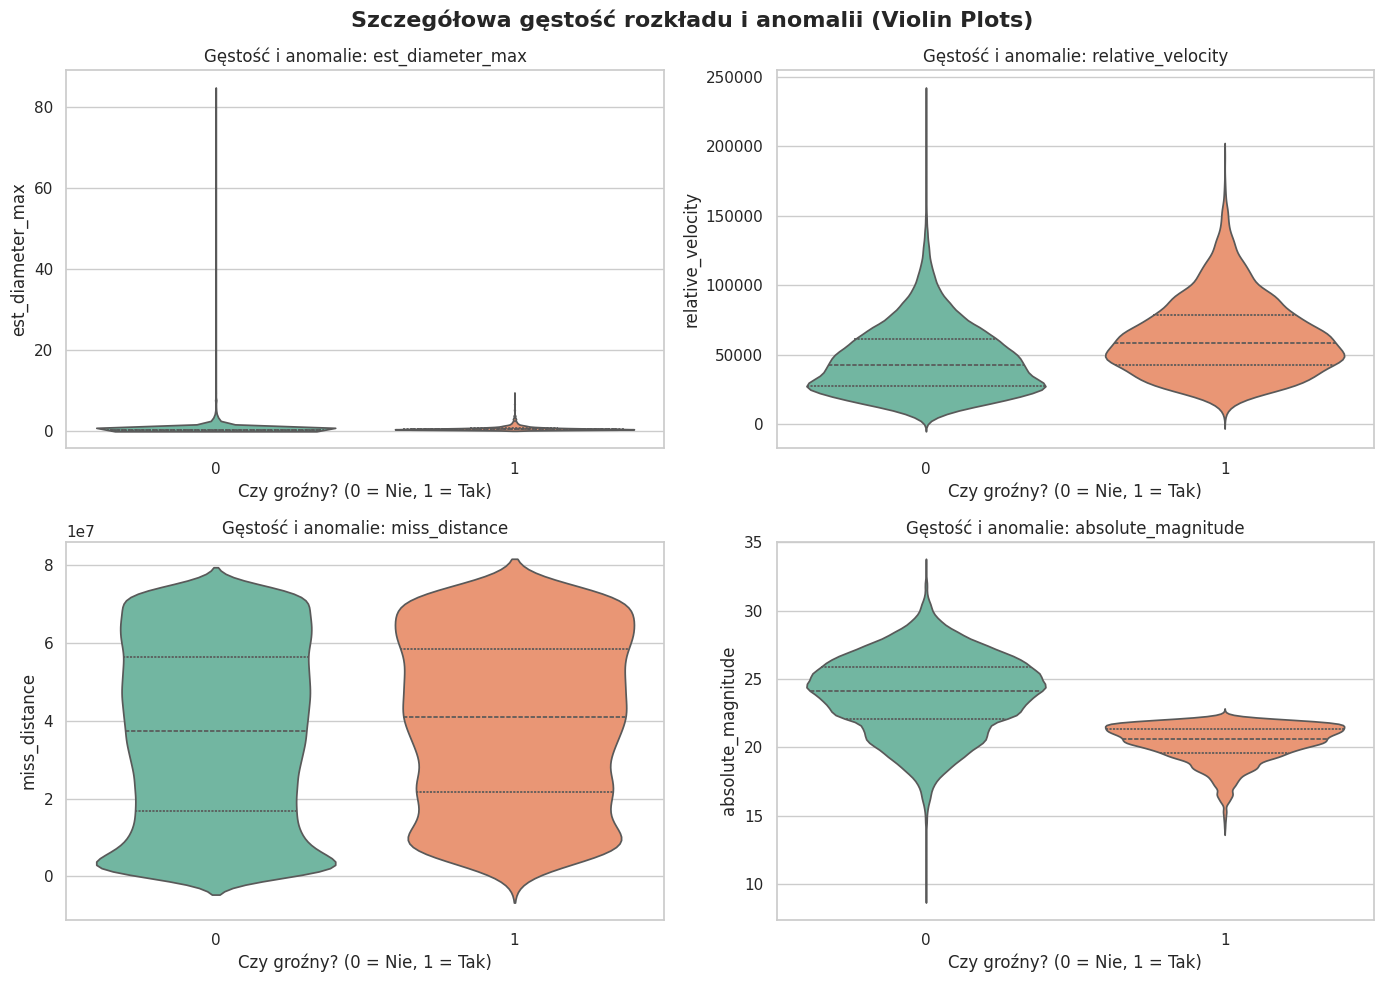

In [ ]:
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Szczegółowa gęstość rozkładu i anomalii (Violin Plots)', fontsize=16, fontweight='bold')

for ax, feature in zip(axes.flatten(), feats_to_plot):
    sns.violinplot(
        x='hazardous',
        y=feature,
        data=df_analysis,
        ax=ax,
        palette='Set2',
        inner='quartile'
    )
    ax.set_title(f'Gęstość i anomalie: {feature}')
    ax.set_xlabel('Czy groźny? (0 = Nie, 1 = Tak)')

plt.tight_layout()
plt.show()

`est_diameter_max` - największe obiekty są sklasyfikowane jako bezpieczne, a niebezpieczne nie przekraczają 20km. Zapewne wynika to z faktu, że większe obiekty łatwiej analizować.

`relative_velocity` - asteroidy z większymi prędkościami mają większą szansę na sklasyfikowanie jako zagrożenie

`miss_distance` - wykresy są podobne, więc sam fakt bliskiego przelotu nie ma większego wpływu na decyzję o zaklasyfikowaniu jako groźny

`absolute_magnitude` - widać wyraźną różnicę między klasami

## 6. Przetwarzanie danych
Przygotowanie danych do nauki modelu, normalizacja / standaryzacja, podział zbioru na część treningową i testową.

#### 6.1 Wyrzucenie niepotrzebnych danych
Usunięcie kolumn ktore nie wpływaja na zagroenie / są takie same (jak np planeta wszedzie ziemia)

In [14]:
df_clean = df.copy()

# id i name nic nie daja modelowi
df_clean = df_clean.drop(['id', 'name'], axis=1)

# Wszystkie to ziemia
if df_clean['orbiting_body'].nunique() == 1:
    df_clean = df_clean.drop('orbiting_body', axis=1)

# Czy jakies obiekty nie sa w systemie
if df_clean['sentry_object'].nunique() == 1:
    df_clean = df_clean.drop('sentry_object', axis=1)
elif 'sentry_object' in df_clean.columns:
    df_clean['sentry_object'] = df_clean['sentry_object'].astype(int)


# Zamiana zagrozeń na int
df_clean['hazardous'] = df_clean['hazardous'].astype(int)

#### 6.2 Normalizacja / standaryzacja danych

In [ ]:
#To DO
# ja ci dam To DO, jest w komórce niżej StandardScaler()

#### 6.3 Podział danych (testowe i treningowe)
Podział danych na testowe i treningowe, zeby był testowany na danych ktorych nei widział podczas sanuki w celu sprawdzenia czy nie dopasowuje sie ndo danych (overfitting)

In [15]:
X = df_clean.drop('hazardous', axis=1)
y = df_clean['hazardous']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f"Rozmiar zbioru treningowego: {X_train_scaled.shape[0]} probek")
print(f"Rozmiar zbioru testowego: {X_test_scaled.shape[0]} probek")

Rozmiar zbioru treningowego: 72668 probek
Rozmiar zbioru testowego: 18168 probek


## 7. Modelowanie i walidacja
Budowa modeli klasyfikacyjnych.Ze względu na duze koszty pomyłek, dobór odpowiedniego progu odcięcia (threshold) i metryk balansujących precyzję i czułość.

Podzial pracy:
* Przemek: SVM + drzewo decyzyjne
* Tomek: MLP + Regresja logistyczna + DeepLearning
* Mateusz: KNN + Naiwny Bayes

#### 7.1 MLP
Wykorzystanie wielowarstwowego perceptronu (**MLP**), ze stałymi parametrami uczenia, skupiając się na zbadaniu wpływu hiperparametrów regularyzacji.

* **Struktura:** Warianty takie jak: `(16,)`, `(32,)`, `(16, 8)`.
* **Parametry stałe:** Optymalizator: `Adam`, Funkcja aktywacji: `ReLU`.
* **Badany parametr:** **Regularyzacja (alpha)** – parametr kary L2.


In [33]:
param_grid_mlp = {
    'hidden_layer_sizes': [(16,), (32,), (256,), (32, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.001, 0.01, 0.1, 0.5],
}

scoring_metrics = {'Recall': 'recall', 'Precision': 'precision', 'F1': 'f1'}

base_mlp = MLPClassifier(max_iter=1000, random_state=42)

grid_search_mlp= GridSearchCV(
    estimator=base_mlp,
    param_grid=param_grid_mlp,
    cv=5,
    scoring=scoring_metrics,
    refit='Recall',
    n_jobs=-1,
)

grid_search_mlp.fit(X_train_scaled, y_train)
print(f"Najlepsze parametry (pod kątem Recall): {grid_search_mlp.best_params_}")


Najlepsze parametry (pod kątem Recall): {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (16,), 'solver': 'adam'}


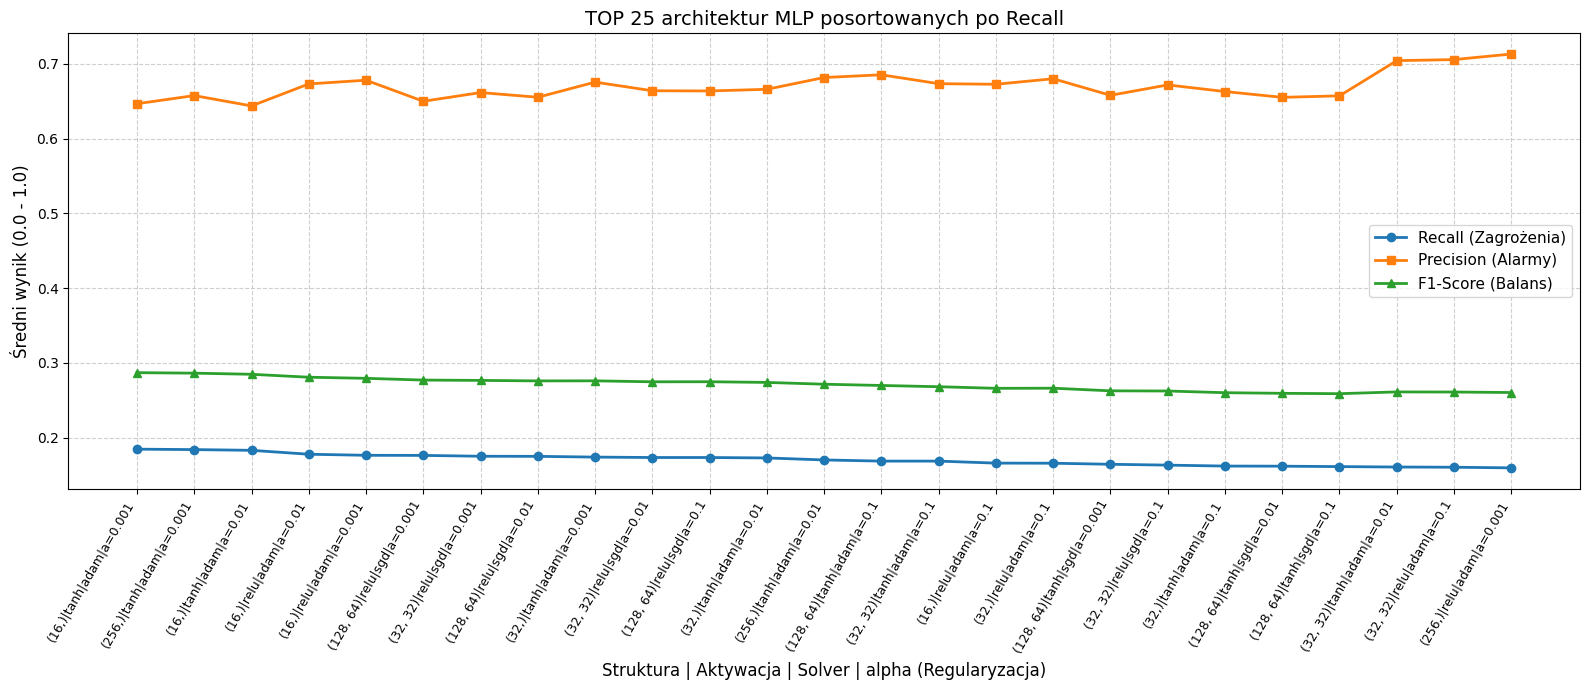

In [34]:
results_mlp = pd.DataFrame(grid_search_mlp.cv_results_)
results_mlp['name'] = (
    results_mlp['param_hidden_layer_sizes'].astype(str) + "|"
    + results_mlp['param_activation'].astype(str) + "|"
    + results_mlp['param_solver'].astype(str) + "|a="
    + results_mlp['param_alpha'].astype(str)
)
results_mlp_sorted = results_mlp.sort_values(
    by='mean_test_Recall', ascending=False
).head(25)

plt.figure(figsize=(16, 7))
plt.plot(
    results_mlp_sorted['name'],
    results_mlp_sorted['mean_test_Recall'],
    marker='o',
    linewidth=2,
    label='Recall (Zagrożenia)',
)
plt.plot(
    results_mlp_sorted['name'],
    results_mlp_sorted['mean_test_Precision'],
    marker='s',
    linewidth=2,
    label='Precision (Alarmy)',
)
plt.plot(
    results_mlp_sorted['name'],
    results_mlp_sorted['mean_test_F1'],
    marker='^',
    linewidth=2,
    label='F1-Score (Balans)',
)


plt.title("TOP 25 architektur MLP posortowanych po Recall", fontsize=14)
plt.xlabel("Struktura | Aktywacja | Solver | alpha (Regularyzacja)", fontsize=12)
plt.ylabel("Średni wynik (0.0 - 1.0)", fontsize=12)
plt.xticks(rotation=60, ha='right', fontsize=9)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()



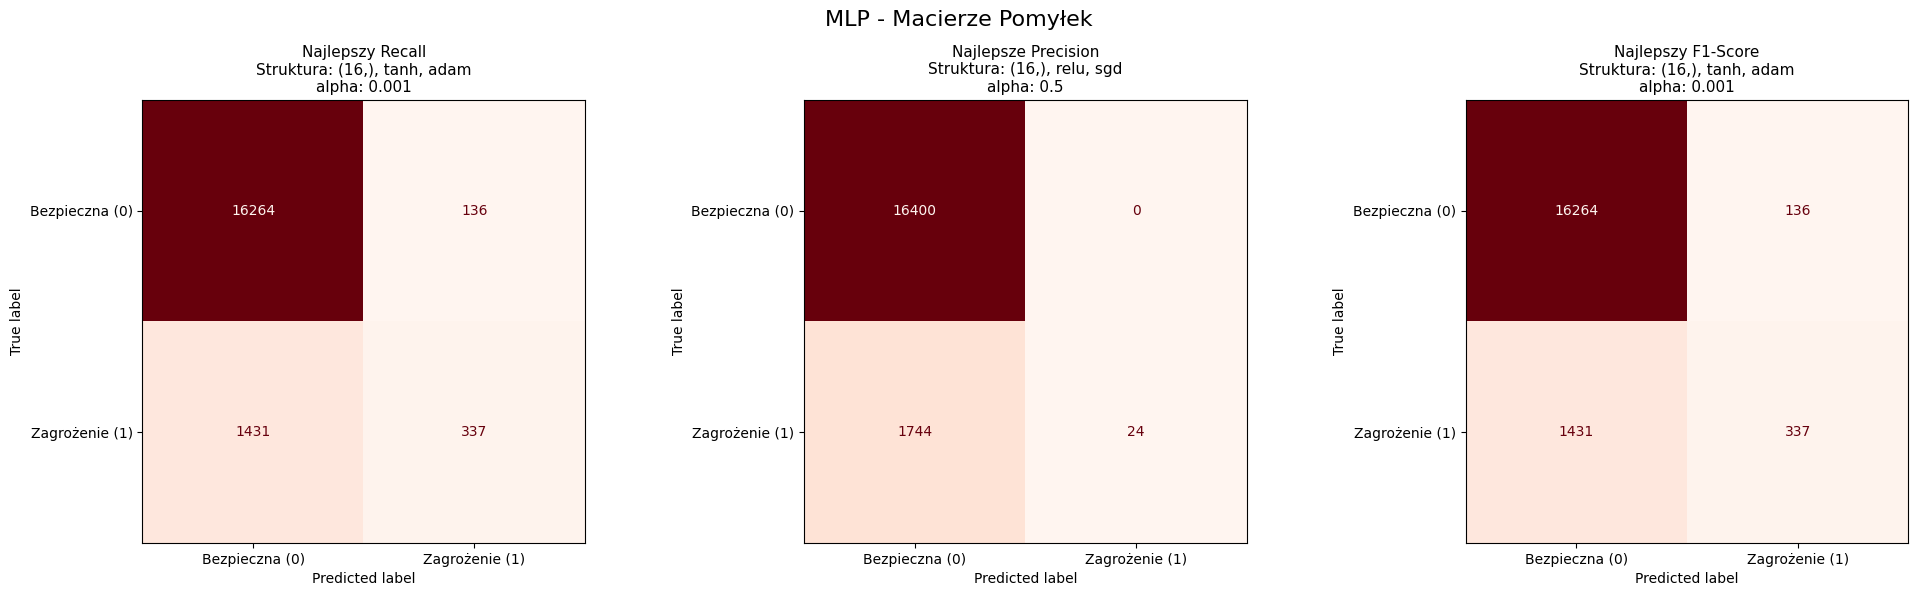

In [37]:
best_recall_idx = results_mlp['mean_test_Recall'].idxmax()
best_precision_idx = results_mlp['mean_test_Precision'].idxmax()
best_f1_idx = results_mlp['mean_test_F1'].idxmax()

best_configs_mlp = {
    'Najlepszy Recall': results_mlp.loc[best_recall_idx, 'params'],
    'Najlepsze Precision': results_mlp.loc[best_precision_idx, 'params'],
    'Najlepszy F1-Score': results_mlp.loc[best_f1_idx, 'params'],
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (nazwa, parametry) in zip(axes, best_configs_mlp.items()):
    model = MLPClassifier(max_iter=1000, random_state=42, **parametry)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=['Bezpieczna (0)', 'Zagrożenie (1)']
    )
    disp.plot(cmap='Reds', ax=ax, colorbar=False)

    layers_str = str(parametry['hidden_layer_sizes'])
    act = parametry['activation']
    sol = parametry['solver']
    alp = parametry['alpha']

    ax.set_title(
        f"{nazwa}\nStruktura: {layers_str}, {act}, {sol}\nalpha: {alp}",
        fontsize=11,
    )

plt.suptitle("MLP - Macierze Pomyłek", fontsize=16)
plt.tight_layout()

plt.show()

Teraz ze zbalansowanymi danymi

Rozmiar przed SMOTE: (72668, 5)
Rozmiar po SMOTE:   (131192, 5)


/Users/tomekorman/Documents/PWR/Semestr 2/Uczenie maszynowe/Laboratoria/Lista_4_projekt/lista-4-projekt-grupowy-orjaol/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



Najlepsze parametry: {'activation': 'tanh', 'alpha': 0.1, 'hidden_layer_sizes': (128, 64), 'solver': 'sgd'}


<Figure size 700x600 with 0 Axes>

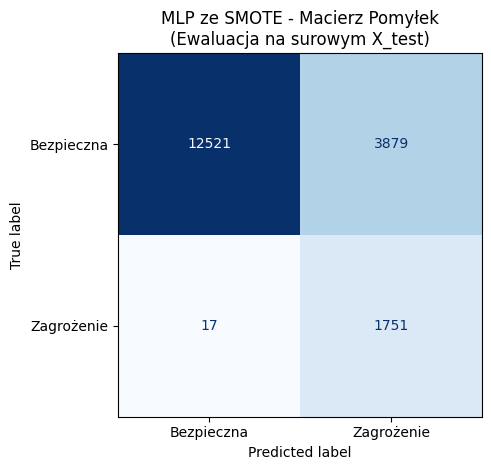

In [38]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Rozmiar przed SMOTE: {X_train_scaled.shape}")
print(f"Rozmiar po SMOTE:   {X_train_smote.shape}")



grid_search_mlp.fit(X_train_smote, y_train_smote)

print(f"\nNajlepsze parametry: {grid_search_mlp.best_params_}")

best_mlp = grid_search_mlp.best_estimator_
y_pred_mlp = best_mlp.predict(X_test_scaled)


cm = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['Bezpieczna', 'Zagrożenie']
)

plt.figure(figsize=(7, 6))
disp.plot(cmap='Blues', colorbar=False)
plt.title("MLP ze SMOTE - Macierz Pomyłek\n(Ewaluacja na surowym X_test)")
plt.grid(False)
plt.tight_layout()

plt.show()

#### 7.2 Deep Learning (Głębokie Uczenie)
Wykorzystanie wielowarstwowej, głębokiej sieci neuronowej w celu sprawdzenia, czy architektura o większej liczbie warstw ukrytych lepiej wyłapie złożone i nieliniowe zależności w danych o asteroidach w porównaniu do klasycznego, płytkiego modelu MLP.

In [ ]:
#TO DO
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)

class_weights_dict = {0: weights[0], 1: weights[1]}
print(f"Wyliczone wagi: Bezpieczna(0) = {weights[0]:.2f}, Zagrożenie(1) = {weights[1]:.2f}")



model = Sequential(
    [
        Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.3),

        Dense(64, activation='relu'),
        Dropout(0.3),

        Dense(32, activation='relu'),

        Dense(1, activation='sigmoid'),
    ]
)


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision'),
    ],
)


early_stop = EarlyStopping(
    monitor='val_recall',
    mode='max',
    patience=15,
    restore_best_weights=True,
)


history = model.fit(
    X_train_scaled,
    y_train,
    epochs=150,
    batch_size=64,
    class_weight=class_weights_dict,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)



Wyliczone wagi: Bezpieczna(0) = 0.55, Zagrożenie(1) = 5.14
Epoch 1/150


/Users/tomekorman/Documents/PWR/Semestr 2/Uczenie maszynowe/Laboratoria/Lista_4_projekt/lista-4-projekt-grupowy-orjaol/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


909/909 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3996 - precision: 0.2821 - recall: 0.9145 - val_loss: 0.3721 - val_precision: 0.2956 - val_recall: 0.9964
Epoch 2/150
909/909 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3122 - precision: 0.2953 - recall: 0.9878 - val_loss: 0.3479 - val_precision: 0.3029 - val_recall: 0.9886
Epoch 3/150
909/909 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3068 - precision: 0.3052 - recall: 0.9899 - val_loss: 0.3845 - val_precision: 0.2986 - val_recall: 0.9936
Epoch 4/150
909/909 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3105 - precision: 0.3045 - recall: 0.9881 - val_loss: 0.3698 - val_precision: 0.3042 - val_recall: 0.9893
Epoch 5/150
909/909 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3067 - precision: 0.3067 - recall: 0.9879 - val_loss: 0.3698 - val_precision: 0.3072 - val_recall: 0.9914
Epoch 6/150
909/909 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3007 - precision: 0.3056 - recall: 0.9874 - val_loss: 0.3565 - val_precision: 0.3050 - val_recall: 0.990

In [21]:
y_pred_probs = model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.5).astype(int)

568/568 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step


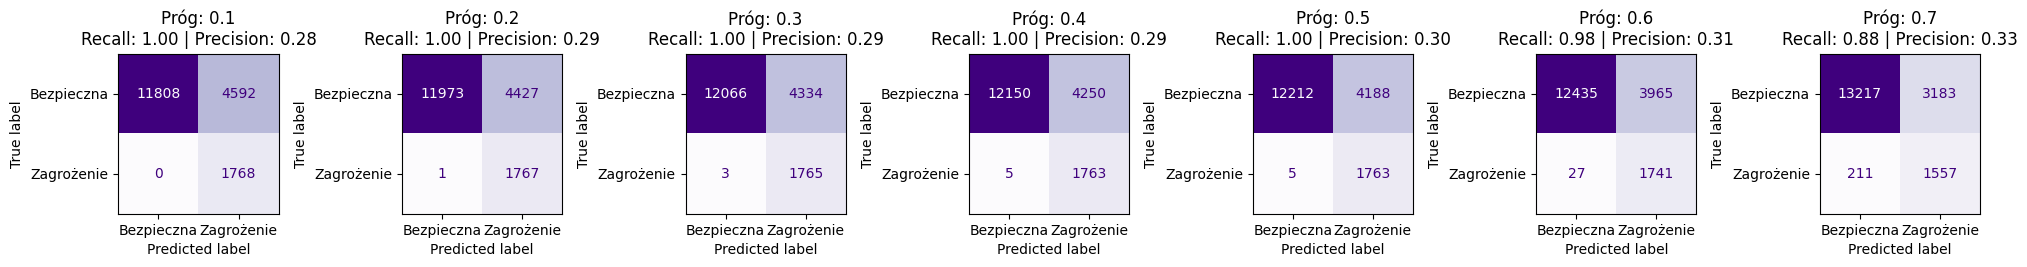

In [28]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

fig, axes = plt.subplots(1, 7, figsize=(20, 6))

for i, t in enumerate(thresholds):
    y_pred_t = (y_pred_probs > t).astype(int)
    
    cm = confusion_matrix(y_test, y_pred_t)
    
    rec = recall_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bezpieczna', 'Zagrożenie'])
    disp.plot(cmap='Purples', ax=axes[i], colorbar=False)
    
    axes[i].set_title(f"Próg: {t}\nRecall: {rec:.2f} | Precision: {prec:.2f}")
    axes[i].grid(False)

plt.tight_layout()
plt.show()

#### 7.3 Naiwny Bayes
Zastosowanie klasyfikatora **Naiwnego Bayesa** z optymalizacją parametru wygładzania oraz porównaniem różnych wariantów tej metody (np. wariantu gaussowskiego) dla naszych danych.

In [ ]:
#To DO
X_train_nb = X_train_scaled.drop('est_diameter_min', axis=1)
X_test_nb = X_test_scaled.drop('est_diameter_min', axis=1)

=== Trenowanie modelu ===


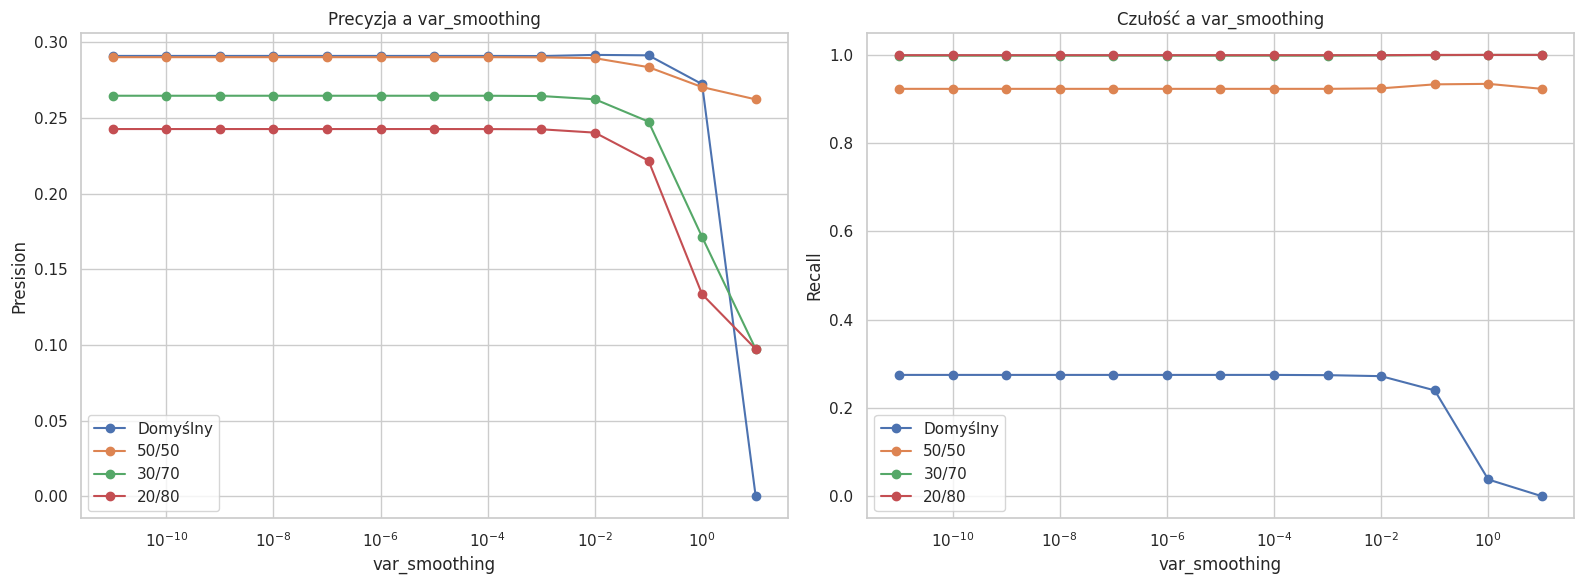

In [ ]:
var_smoothings = [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]
priors_list = [None, [0.5, 0.5], [0.3, 0.7], [0.2, 0.8]]
priors_names = ['Domyślny', '50/50', '30/70', '20/80']

results_presision = {label: [] for label in priors_names}
results_recall = {label: [] for label in priors_names}

print("=== Trenowanie modelu ===")

for prior, prior_name in zip(priors_list, priors_names):
    for var_smoothing in var_smoothings:
      model = GaussianNB(priors=prior, var_smoothing=var_smoothing)
      model.fit(X_train_nb, y_train)
      y_pred = model.predict(X_test_nb)
      results_presision[prior_name].append(precision_score(y_test, y_pred, zero_division=0))
      results_recall[prior_name].append(recall_score(y_test, y_pred, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for label in priors_names:
  axes[0].plot(var_smoothings, results_presision[label], label=label, marker='o')
  axes[1].plot(var_smoothings, results_recall[label], label=label, marker='o')
for ax in axes:
  ax.set_xscale('log')
  ax.set_xlabel('var_smoothing')
  ax.grid(True)
  ax.legend()
axes[0].set_ylabel('Presision')
axes[1].set_ylabel('Recall')
axes[0].set_title('Precyzja a var_smoothing')
axes[1].set_title('Czułość a var_smoothing')
plt.tight_layout()
plt.show()

=== Raport dla modelu kompromisowego ===
              precision    recall  f1-score   support

           0       0.99      0.75      0.85     16400
           1       0.28      0.93      0.44      1768

    accuracy                           0.76     18168
   macro avg       0.64      0.84      0.64     18168
weighted avg       0.92      0.76      0.81     18168



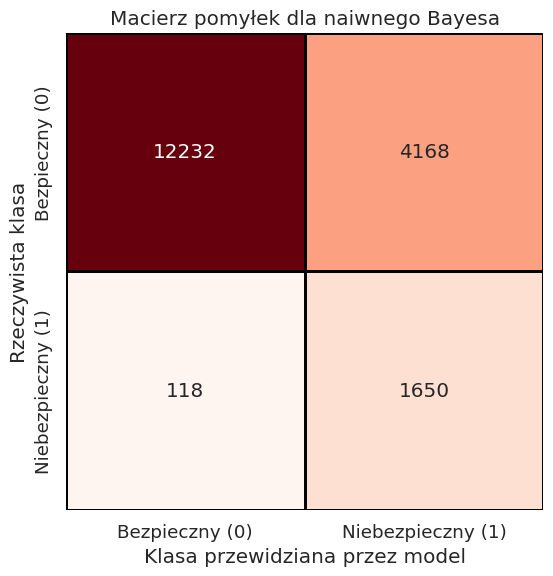

In [ ]:
best_model = GaussianNB(var_smoothing=1e-1, priors=[0.5, 0.5])
best_model.fit(X_train_nb, y_train)
y_pred = best_model.predict(X_test_nb)

print("=== Raport dla modelu kompromisowego ===")
print(classification_report(y_test, y_pred))

cm =confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid", font_scale=1.2)
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False, square=True, linewidths=1, linecolor='black')
ax.set_xticklabels(['Bezpieczny (0)', 'Niebezpieczny (1)'])
ax.set_yticklabels(['Bezpieczny (0)', 'Niebezpieczny (1)'])
plt.title("Macierz pomyłek dla naiwnego Bayesa")
plt.xlabel('Klasa przewidziana przez model')
plt.ylabel('Rzeczywista klasa')
plt.tight_layout()
plt.show()

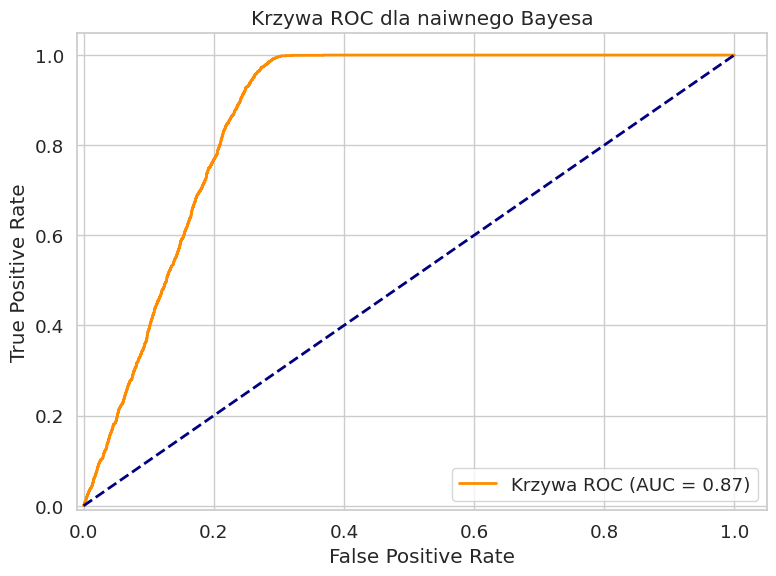

In [ ]:
y_prob_nb = best_model.predict_proba(X_test_nb)[:, 1]
fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_test, y_prob_nb)
roc_auc_nb = roc_auc_score(y_test, y_prob_nb)

plt.figure(figsize=(8,6))
plt.plot(fpr_nb, tpr_nb, color='darkorange', lw=2, label=f'Krzywa ROC (AUC = {roc_auc_nb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.05])
plt.ylim([-0.01, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC dla naiwnego Bayesa')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### Wnioski - Naiwny Bayes
Czy Naiwny Bayes jest dobrym klasyfikatorem dla tego projektu? Raczej nie.

Krzywa ROC z wynikiem $AUC = 0.87$ oznacza, że model w 87% przypadków poprawnie oceni, że losowa groźna asteroida ma wyższe prawdopodobieństwo uderzenia w Ziemię niż losowa bezpieczna. Jednak wystarczy spojrzeć na macierz pomyłek by dostrzec negatywny wpływ próby zachowania kompromisu między precyzją i czułością.

Model z domyślnym parametrem `priors` pominął ponad 1300 zagrożeń, ale po dobraniu odpiowiednich wartości udało się zbić tą wartość do zaledwie 118. Jednak prawdziwy problem pojawia się z bardzo kosztownymi fałszywymi alarmami, których jest ponad 4000. Agencje kosmiczne zbankrutowałyby.

Głównymi wadami Naiwnego Bayesa jest założenie o niezależności cech, co w naszym przypadku doprowadzi do tragedii oraz próba wciśnięcia licznych anomalii w idealny dzwon Gaussa.

#### 7.4 SVM
Zastosowanie **SVM** z analizą siły regularyzacji, typu funkcji jądrowej (liniowa vs nieliniowa) oraz ewentualnego ważenia klas, w celu optymalnego oddzielenia obiektów niebezpiecznych od bezpiecznych.

Raport dla SVM

              precision    recall  f1-score   support

           0       1.00      0.74      0.85     16400
           1       0.29      0.99      0.46      1768

    accuracy                           0.77     18168
   macro avg       0.65      0.87      0.65     18168
weighted avg       0.93      0.77      0.81     18168



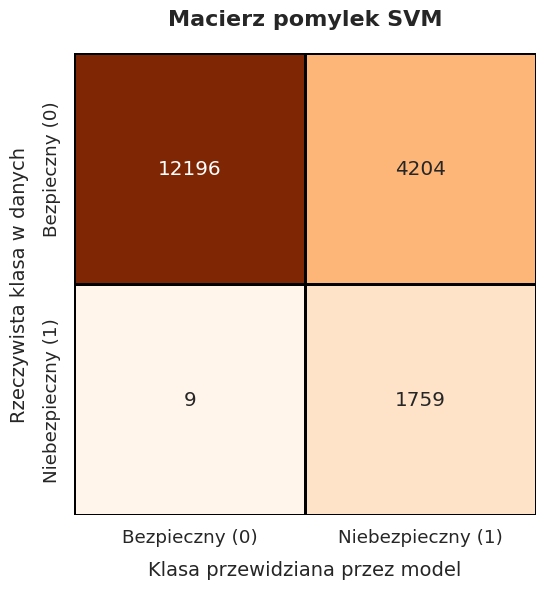

In [ ]:
#TO DO and so begins the stuggle
model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
# rbf bo dla liniowej model uczy sie ze kazdy obiekt jest bezpieczny, 90% acc bezuzyteczny w praktyce
model.fit(X_train_scaled, y_train)
y_pred_SVM = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_SVM)

print("Raport dla SVM\n")
print(classification_report(y_test, y_pred_SVM))

plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid", font_scale=1.2)

ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False, square=True, linewidths=1, linecolor='black')
ax.set_xticklabels(['Bezpieczny (0)', 'Niebezpieczny (1)'])
ax.set_yticklabels(['Bezpieczny (0)', 'Niebezpieczny (1)'])
plt.title('Macierz pomylek SVM', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Klasa przewidziana przez model', fontsize=14, labelpad=10)
plt.ylabel('Rzeczywista klasa w danych', fontsize=14, labelpad=10)

plt.show()

#### 7.5 Drzewa decyzyjne
* Wykorzystanie pojedynczego **drzewa decyzyjnego** z badaniem maksymalnej głębokości, pruningu i ważenia klas, zeby znaleźć wariant, który nie ulega przeuczeniu na zbiorze.

* Wykorzystanie **lasu losowego** w celu sprawdzenia czy dla naszego problemu daje lepsze rezultaty.

Raport dla drzewa

              precision    recall  f1-score   support

           0       1.00      0.77      0.87     16400
           1       0.31      0.99      0.48      1768

    accuracy                           0.79     18168
   macro avg       0.66      0.88      0.67     18168
weighted avg       0.93      0.79      0.83     18168



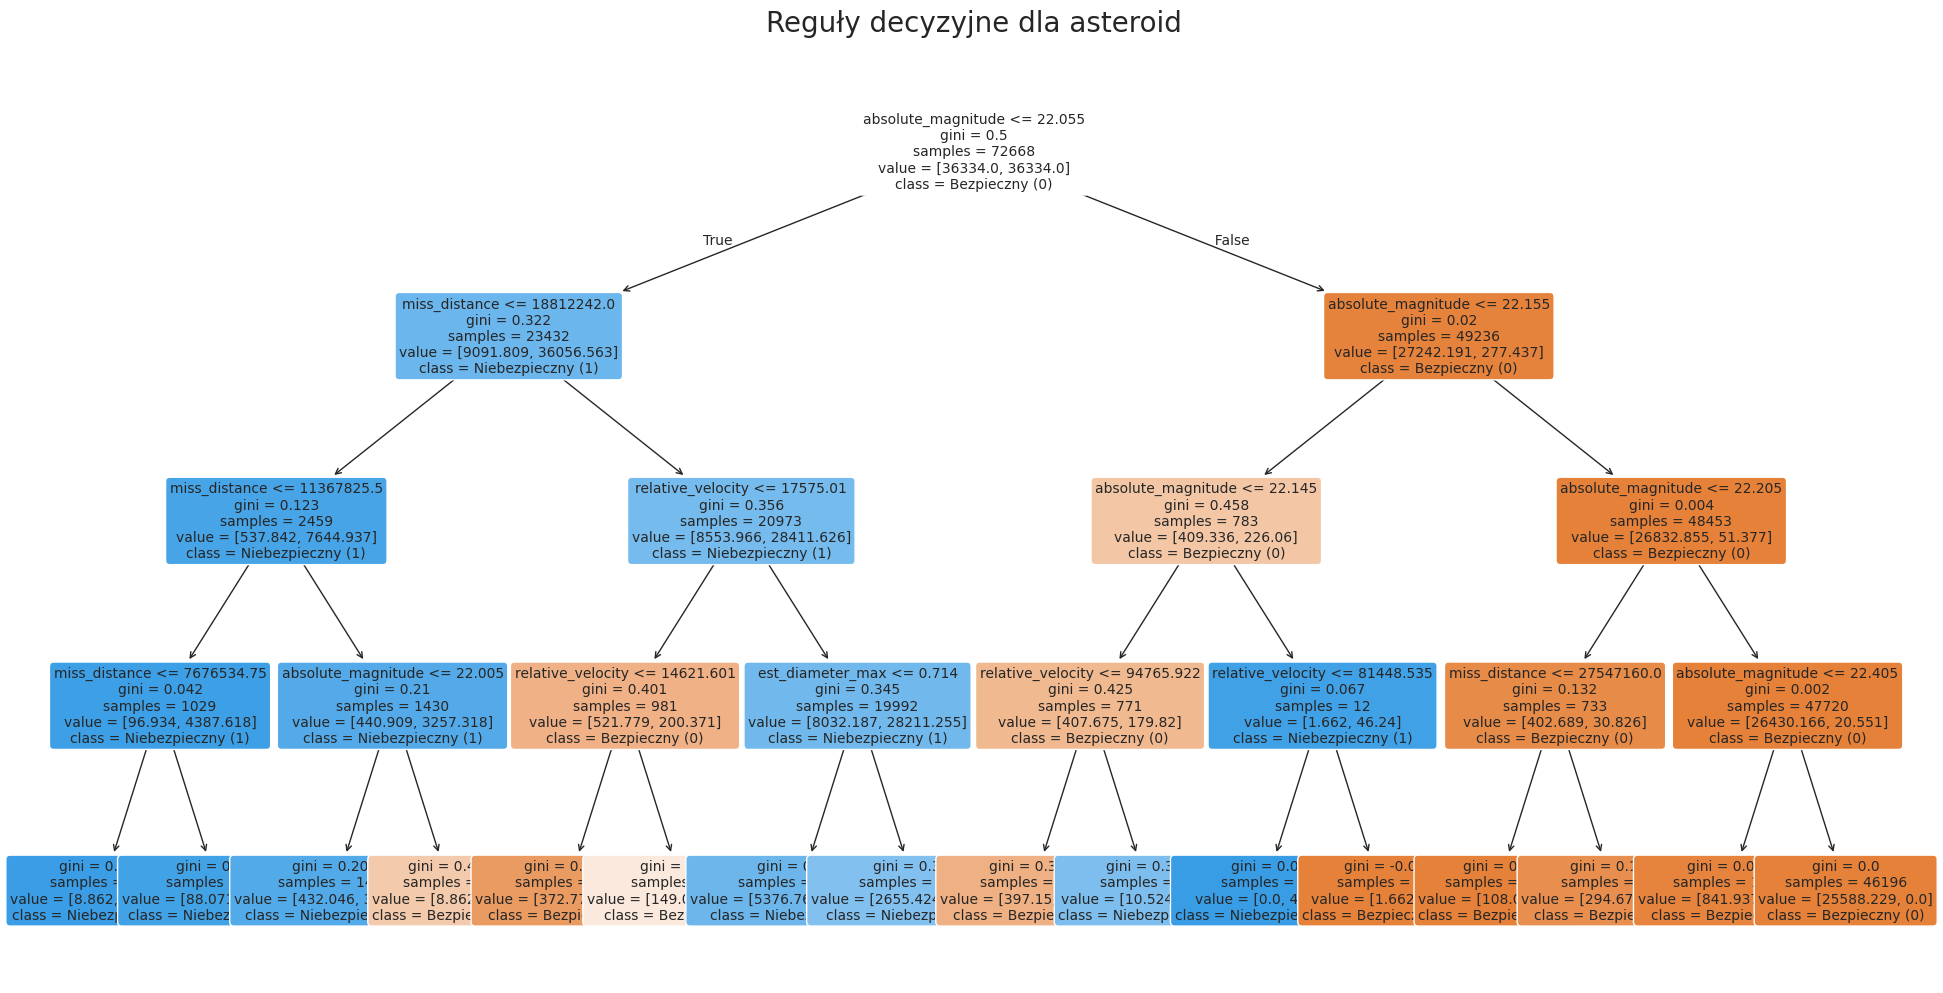

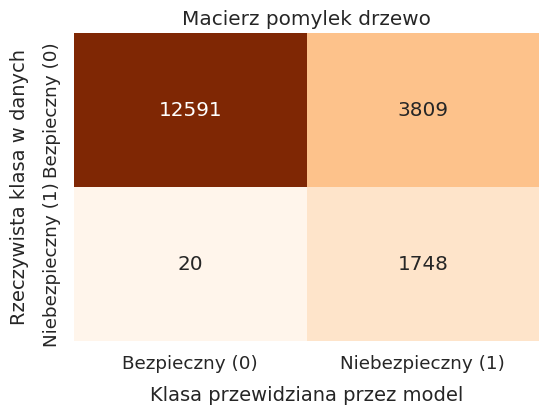

In [ ]:
#TO DO
dt_model = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Raport dla drzewa\n")
print(classification_report(y_test, y_pred_dt))

plt.figure(figsize=(24, 12))
plot_tree(dt_model, feature_names=X.columns, class_names=['Bezpieczny (0)', 'Niebezpieczny (1)'], filled=True, rounded=True, fontsize=10)
plt.title('Reguły decyzyjne dla asteroid', fontsize=20, pad=20)
plt.show()

plt.figure(figsize=(6, 4))
ax = sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Oranges', cbar=False)
ax.set_xticklabels(['Bezpieczny (0)', 'Niebezpieczny (1)'])
ax.set_yticklabels(['Bezpieczny (0)', 'Niebezpieczny (1)'])
plt.title('Macierz pomylek drzewo')
plt.xlabel('Klasa przewidziana przez model', fontsize=14, labelpad=10)
plt.ylabel('Rzeczywista klasa w danych', fontsize=14, labelpad=10)
plt.show()

Raport las

              precision    recall  f1-score   support

           0       0.94      0.97      0.96     16400
           1       0.62      0.39      0.48      1768

    accuracy                           0.92     18168
   macro avg       0.78      0.68      0.72     18168
weighted avg       0.91      0.92      0.91     18168



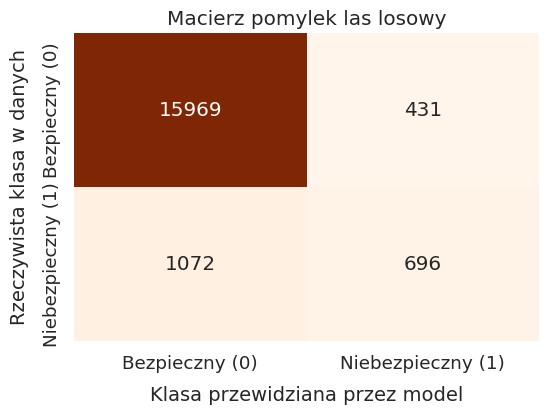

In [ ]:
rf_model = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Raport las\n")
print(classification_report(y_test, y_pred_rf))

plt.figure(figsize=(6, 4))
ax = sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Oranges', cbar=False)
ax.set_xticklabels(['Bezpieczny (0)', 'Niebezpieczny (1)'])
ax.set_yticklabels(['Bezpieczny (0)', 'Niebezpieczny (1)'])
plt.title('Macierz pomylek las losowy')
plt.xlabel('Klasa przewidziana przez model', fontsize=14, labelpad=10)
plt.ylabel('Rzeczywista klasa w danych', fontsize=14, labelpad=10)
plt.show()

#### 7.6 Regresja logistyczna
Zbudowanie modelu **regresji logistycznej** poprzedzonego wstępną selekcją cech, z jednoczesnym badaniem wpływu siły i rodzaju regularyzacji na ostateczny wynik klasyfikacji.

In [ ]:
#TO DO
df_lr = df_clean.drop('est_diameter_max', axis=1)

X_lr = df_lr.drop('hazardous', axis=1)
y_lr = df_lr['hazardous']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr)

scaler = StandardScaler()

X_train_scaled_lr = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled_lr = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f"Rozmiar zbioru treningowego: {X_train_scaled_lr.shape[0]} probek")
print(f"Rozmiar zbioru testowego: {X_test_scaled_lr.shape[0]} probek")



Rozmiar zbioru treningowego: 72668 probek
Rozmiar zbioru testowego: 18168 probek


In [ ]:
x

Najlepsze parametry (wybrane pod kątem Recall): {'C': 0.01, 'class_weight': 'balanced', 'solver': 'liblinear'}


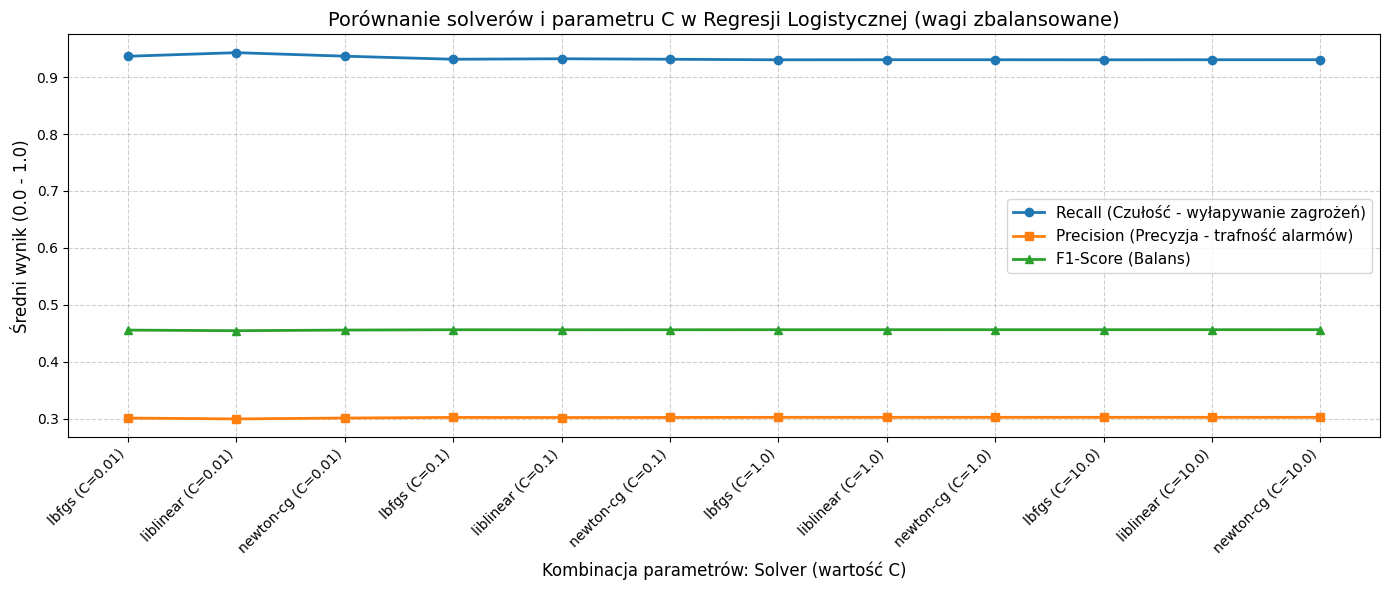

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(results['nazwa'], results['mean_test_Recall'], marker='o', linewidth=2, label='Recall (Czułość - wyłapywanie zagrożeń)')
plt.plot(results['nazwa'], results['mean_test_Precision'], marker='s', linewidth=2, label='Precision (Precyzja - trafność alarmów)')
plt.plot(results['nazwa'], results['mean_test_F1'], marker='^', linewidth=2, label='F1-Score (Balans)')

plt.title("Porównanie solverów i parametru C w Regresji Logistycznej (wagi zbalansowane)", fontsize=14)
plt.xlabel("Kombinacja parametrów: Solver (wartość C)", fontsize=12)
plt.ylabel("Średni wynik (0.0 - 1.0)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

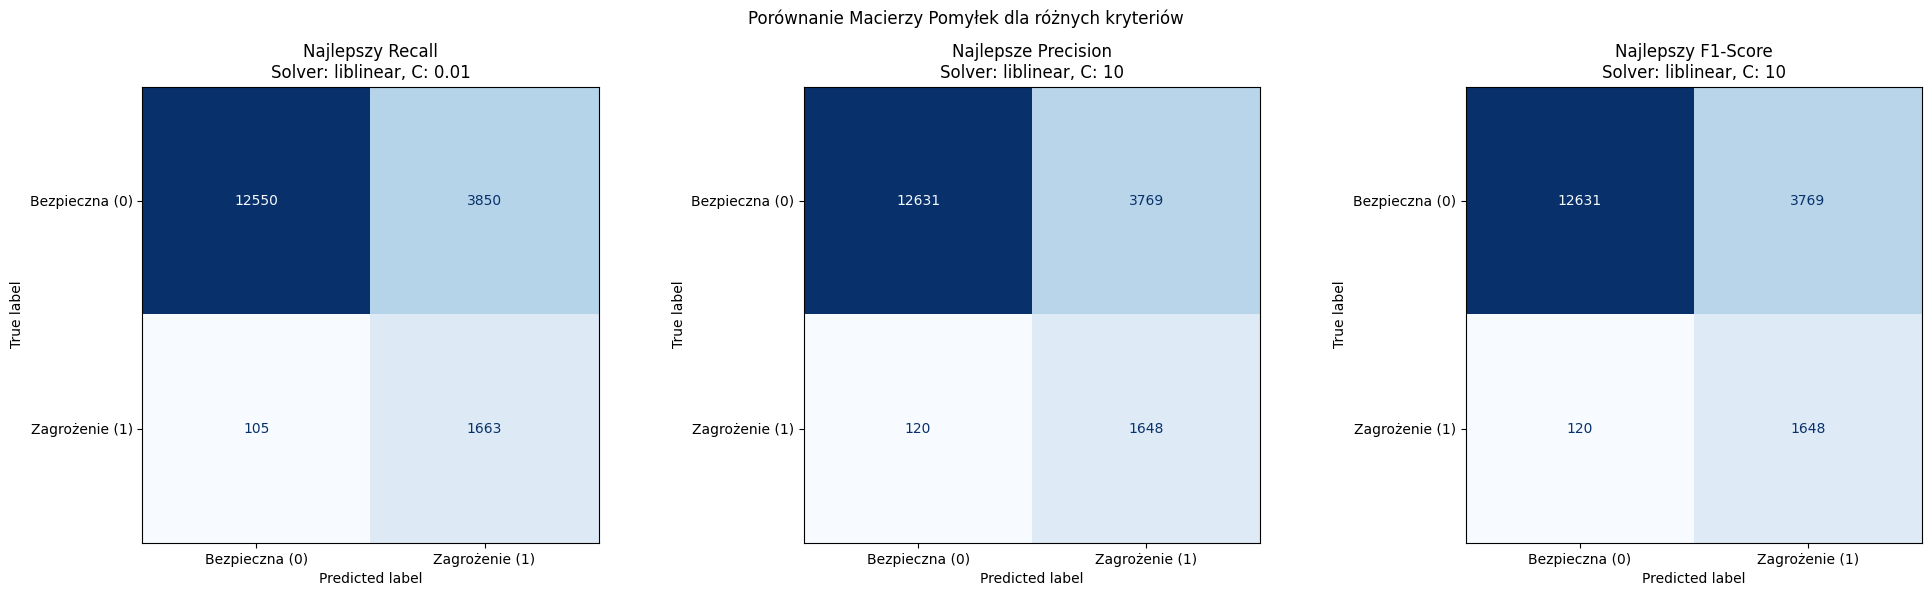

In [ ]:
best_recall_idx = results['mean_test_Recall'].idxmax()
best_precision_idx = results['mean_test_Precision'].idxmax()
best_f1_idx = results['mean_test_F1'].idxmax()

params_recall = results.loc[best_recall_idx, 'params']
params_precision = results.loc[best_precision_idx, 'params']
params_f1 = results.loc[best_f1_idx, 'params']

best_configs = {
    'Najlepszy Recall': params_recall,
    'Najlepsze Precision': params_precision,
    'Najlepszy F1-Score': params_f1,
}


fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, params) in zip(axes, best_configs.items()):
    model = LogisticRegression(random_state=42, max_iter=1000, **params)

    model.fit(X_train_scaled_lr, y_train_lr)

    y_pred = model.predict(X_test_scaled_lr)

    cm = confusion_matrix(y_test_lr, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bezpieczna (0)', 'Zagrożenie (1)'])
    disp.plot(cmap='Blues', ax=ax, colorbar=False)

    solver_name = params['solver']
    c_val = params['C']
    ax.set_title(f"{name}\nSolver: {solver_name}, C: {c_val}", fontsize=12)


plt.suptitle("Porównanie Macierzy Pomyłek dla różnych kryteriów")
plt.tight_layout()

plt.show()

#### 7.7 KNN
Wykorzystanie klasyfikatora **KNN** badając wpływ liczby sąsiadów oraz dobranej metryki odległości na trafność predykcji.

In [ ]:
#TO DO
X_train_knn = X_train_scaled.drop('est_diameter_min', axis=1)
X_test_knn = X_test_scaled.drop('est_diameter_min', axis=1)

In [ ]:
knn_model = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

print("=== Dobór hiperparametrów ===")
grid_search_knn = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("=== Trenowanie modelu ===")
grid_search_knn.fit(X_train_knn, y_train)
print("=== Wyniki ===")
print("Najlepsze parametry:", grid_search_knn.best_params_)
print(f"Najlepszy recall: {grid_search_knn.best_score_:.3f}")

=== Dobór hiperparametrów ===
=== Trenowanie modelu ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits
=== Wyniki ===
Najlepsze parametry: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Najlepszy recall: 0.383


=== Raport dla KNN ===
              precision    recall  f1-score   support

           0       0.94      0.95      0.94     16400
           1       0.48      0.41      0.44      1768

    accuracy                           0.90     18168
   macro avg       0.71      0.68      0.69     18168
weighted avg       0.89      0.90      0.90     18168



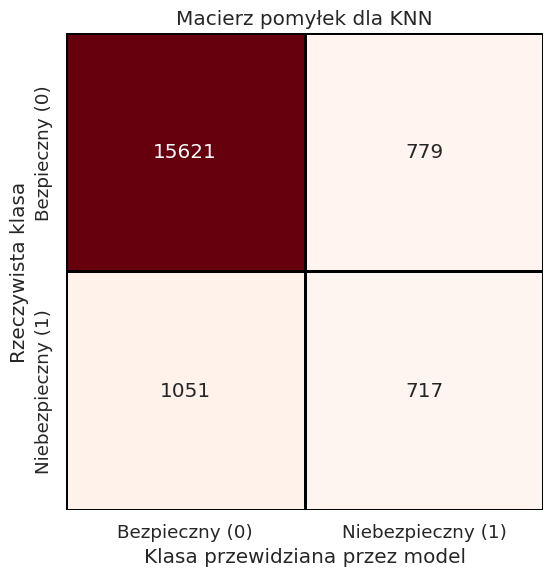

In [ ]:
best_knn = grid_search_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_knn)

print("=== Raport dla KNN ===")
print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8,6))
sns.set_theme(style="whitegrid", font_scale=1.2)
ax = sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Reds', cbar=False, square=True, linewidths=1, linecolor='black')
ax.set_xticklabels(['Bezpieczny (0)', 'Niebezpieczny (1)'])
ax.set_yticklabels(['Bezpieczny (0)', 'Niebezpieczny (1)'])
plt.title("Macierz pomyłek dla KNN")
plt.xlabel('Klasa przewidziana przez model')
plt.ylabel('Rzeczywista klasa')
plt.tight_layout()
plt.show()

=== Trenowanie modelu ===
=== Rysowanie wykresów ===


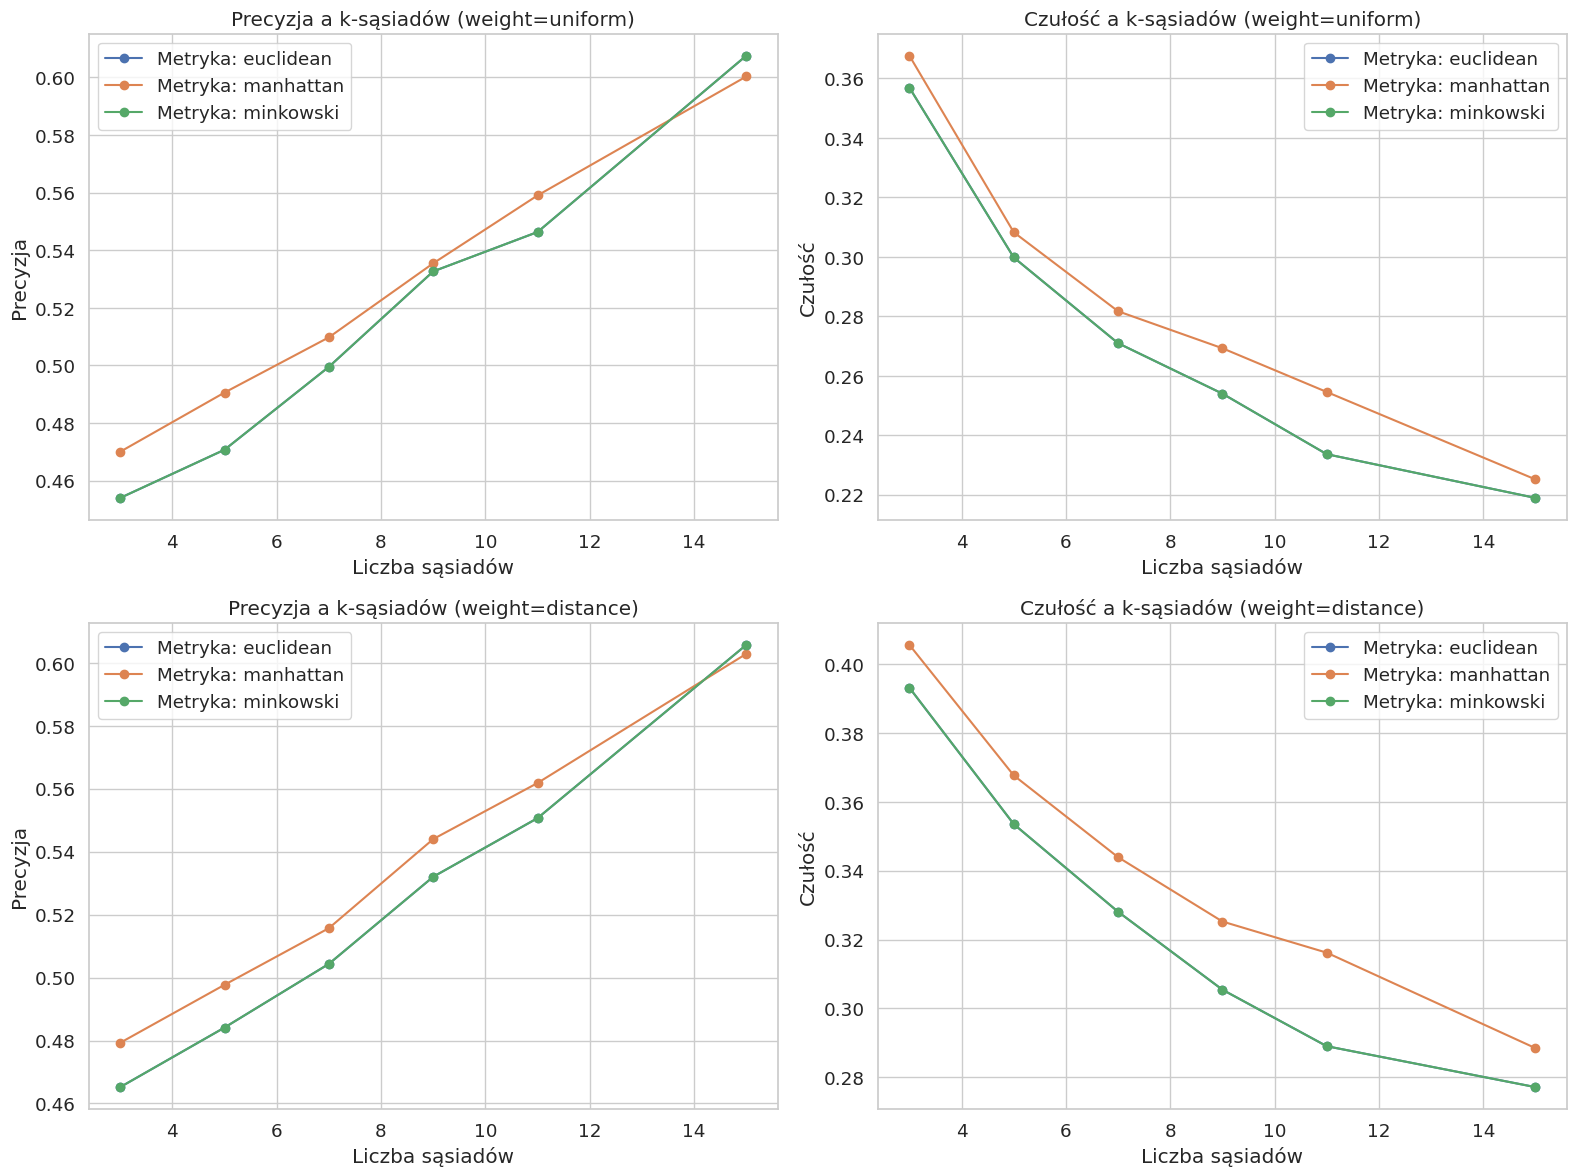

In [ ]:
neighbors_list = [3, 5, 7, 9, 11, 15]
weights_list = ['uniform', 'distance']
metrics_list = ['euclidean', 'manhattan', 'minkowski']

results_precision = {w: {m: [] for m in metrics_list} for w in weights_list}
results_recall = {w: {m: [] for m in metrics_list} for w in weights_list}

print("=== Trenowanie modelu ===")
for weight in weights_list:
    for metric in metrics_list:
        for n_neighbors in neighbors_list:
          knn_model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weight, metric=metric)
          knn_model.fit(X_train_knn, y_train)
          y_pred = knn_model.predict(X_test_knn)
          results_precision[weight][metric].append(precision_score(y_test, y_pred, zero_division=0))
          results_recall[weight][metric].append(recall_score(y_test, y_pred, zero_division=0))

print("=== Rysowanie wykresów ===")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for i, weight in enumerate(weights_list):
    for metric in metrics_list:
        axes[i, 0].plot(neighbors_list, results_precision[weight][metric], label=f'Metryka: {metric}', marker='o')
        axes[i, 1].plot(neighbors_list, results_recall[weight][metric], label=f'Metryka: {metric}', marker='o')
    axes[i, 0].set_title(f"Precyzja a k-sąsiadów (weight={weight})")
    axes[i, 1].set_title(f"Czułość a k-sąsiadów (weight={weight})")

    for j in range(2):
        axes[i, j].set_xlabel('Liczba sąsiadów')
        axes[i, j].grid(True)
        axes[i, j].legend()

axes[0, 0].set_ylabel('Precyzja')
axes[0, 1].set_ylabel('Czułość')
axes[1, 0].set_ylabel('Precyzja')
axes[1, 1].set_ylabel('Czułość')
plt.tight_layout()
plt.show()

Jak widać na wykresach, próba zachowania jakiegokolwiek kompromisu między precyzją a czułością dla naszych danych jest praktycznie niemożliwe.

Wraz ze wzrostem liczby sąsiadów precyzja systematycznie rośnie, jednak równocześnie możemy zauważyć drastyczny spadek czułości.

Dlaczego tak się dzieje? Im większe `k`, tym więcej sąsiadów decyduje o losie danego ciała. A skoro asteroid bezpiecznych mamy zdecydowanie więcej, zatem niemal zawsze przegłosują rzadziej występujące niebezpieczne obiekty. Model staje się bardziej ostrożny jeśli chodzi o fałszywe alarmy (w najlepszym przypadku jest ich tylko blisko 800), ale zdecydowanie częściej przepuszcza faktyczne zagrożenie (ponad 1000 takich asteroid zwiastuje koniec świata)

Lepsze wyniki model osiąga dla metryki `manhattan` oraz dla wagi `distance`, a GridSearch słusznie wskazał także `k=3` jako najbardziej optymalną wartość priorytetyzując czułość.

Jednakże KNN jest bezużyteczny w projekcie z tak silnie niezbalansowanymi danymi. Czułość na poziomie raptem 40% to niemalże gwarancja końca świata.

## 8. Podsumowanie
Analiza macierzy pomyłek, ostateczna ocena i wnioski.

#### Wnioski z analizy modelu MLP (Sieci Neuronowe)

* **1. Ogromny spadek czułości (Recall ~19%):** W przeciwieństwie do Regresji Logistycznej, model MLP całkowicie zawiódł w kwestii obrony planety. Przeoczył aż **1431 z 1768** niebezpiecznych asteroid. Wdrożenie tego modelu oznaczałoby wielokrotną zagładę Ziemi.

* **2. Maksymalna ochrona budżetu (Precision do 100%):** Sieć neuronowa drastycznie ograniczyła fałszywe alarmy. W konfiguracji nastawionej na precyzję model nie wygenerował **ani jednego** fałszywego alarmu (0 zmarnowanych misji).

* **3. Ograniczenia techniczne i brak balansu:** Algorytm `MLPClassifier` w bibliotece `scikit-learn` nie obsługuje automatycznego ważenia klas (`class_weight`). Na zbiorze zdominowanym w ponad 90% przez bezpieczne obiekty (90 tys. wierszy), sieć zoptymalizowała ogólny błąd prawie zawsze przewidując brak zagrożenia.

* **4. Klątwa pojemności (Mniej znaczy więcej):** Rozbudowane architektury (np. 256 neuronów) radziły sobie najgorzej, przeuczaly sie. Najlepszy rezultat uogólniania dała najmniejsza badana sieć **(16,)**, gdzie mała liczba parametrów wymusiła naturalną regularyzację.

* **5. Wykozystanie SMOTE(dane rowno rozlozone)** Udalo sie uzyskac bardzo dobre wyniki prz ({'activation': 'tanh', 'alpha': 0.1, 'hidden_layer_sizes': (128, 64), 'solver': 'sgd'}), tylko 17 nie wykrytych zagrozen, 3979 nie potrzebnych misji co jest calkiem sporo ale w porownaniu co poprzednich wersji ten model jest o wiele lepszy poniewaz bezpieczenstwo ziemi jest priorytetem.

#### Wnioski Deep Learning i Analiza Progów Decyzyjnych
Wdrożenie głębokiej sieci neuronowej (Keras/TensorFlow) z wbudowanym mechanizmem ważenia klas przyniosło **przełomową poprawę** w detekcji obiektów zagrażających Ziemi (klasa `hazardous`), całkowicie deklasując standardowe, płytkie modele MLP ze Scikit-Learn.

##### 1. Wysoka pewność predykcji (Analiza progu odcięcia)
Przeprowadzona analiza progów decyzyjnych (od 0.1 do 0.7) udowodniła, że model jest niezwykle pewny swoich ocen i świetnie separuje przestrzeń:
* **Progi 0.1 – 0.5:** Dają fenomenalne i stabilne rezultaty (Recall ~100%, zaledwie 5 przeoczonych asteroid na kilkanaście tysięcy obiektów testowych). Sieć niemal nie ma niepewności.
* **Granica opłacalności (Próg 0.6 i 0.7):** Podniesienie progu do 0.6 pozwala zaoszczędzić na fałszywych alarmach, ale zwiększa liczbę przeoczeń (False Negatives) do 27. Próg 0.7 jest już zbyt ryzykowny (211 przeoczonych zagrożeń).

##### 2. Koszty (Precision a Recall)
Precyzja (Precision) na poziomie **30-31%** jest w tym konkretnym problemie w pełni akceptowalnym kompromisem. 
* W realiach obrony planetarnej **koszt fałszywego alarmu (False Positive)** – czyli wysłania niepotrzebnej misji badawczej – jest znikomy w porównaniu do ostatecznego **kosztu przeoczenia uderzenia (False Negative)**.
* Model działa jak prawidłowo skalibrowany system wczesnego ostrzegania: woli wszcząć alarm na wyrost, niż dopuścić do pominięcia realnego zagrożenia.

##### Rekomendacja wdrożeniowa
Jako ostateczny model decyzyjny rekomendowana jest **głęboka sieć neuronowa z progiem decyzyjnym (threshold) ustawionym na 0.5**. Zapewnia to maksymalne bezpieczeństwo, nie wymaga potężnego narzutu pamięci RAM na transformacje zbioru i działa błyskawicznie.

#### Wnioski: Regresja Logistyczna a optymalizacja kosztów ryzyka

1. **Obrona planety a koszty (Najlepszy Recall):**
   Model z priorytetem Recall (`C=0.01`, `solver='liblinear'`) znajduje aż 94% zagrożeń, redukując przeoczenia (FN) do 105. Ale, robi to kosztem aż **3850 fałszywych alarmów (FP)**. Uratowalibyśmy Ziemię, ale zmarnowali tysiące miliardów dolarów na niepotrzebne misje, doprowadzając do bankructwa światowe agencje kosmiczne.

2. **Silna regularyzacja (C=0.01) a limity modelu liniowego:**
   Wybór bardzo niskiego parametru `C=0.01` oznacza silną regularyzację – algorytm uczy się tylko najprostszych, najsilniejszych reguł decyzyjnych. Pokazuje to, że regresja logistyczna jest stabilna, ale z racji swojej liniowej natury nie potrafi idealnie oddzielić bezpiecznych obiektów od groźnych bez generowania gigantycznych kosztów finansowych (FP).

3. **Koszty kompromisu (Recall vs Precision/F1):**
   Optymalizacja pod Precision/F1 nieznacznie zmniejsza koszty (spadek fałszywych alarmów z 3850 do 3769, mniej o 81 misji). Jednak model przeoczyl wtedy **15 dodatkowych asteroid (wzrost FN do 120)**. Skoro jeden błąd FN oznacza katastrofę planety, oszczędność finansowa jest tu nieopłacalna.

Wnioski dla SVM, Lasu i drzewa:
        1) SVM dużo fałszywych alarmów, przez przyjęta konwencje model jest duzo mocniej karany za uznanie ze niebezpieczny obiekt jest bezpieczny, dlatego tylko 9 pomyłek ale dlatego też mnóstwo fałszywych alarmów. Wniosek? dział świetnie dla zadanego modelu bo lepiej żeby dawał fałszywy alarm często niż żeby raz pominął niebezpieczną asteroide
        2) Drzewo losowe prawie tak samo jak SVM, ze sposobu w jaki klasyfikujemhy asteroidy niebezpieczne (tzw. MOID – minimalna odległość przecięcia orbity <=0.05 AU oraz absolutna wielkość gwiazdowa H<=22, wspiera tu format działania drzewa) sprawdza sie dobrze, mniej fałszywych alarmów, troche wiecej błędów
        3) Las i jego koszmarne wyniki wynikają z małej ilości niebezpiecznych obiektów, las to wiele drzew, każde dostaje porcje zbioru, nawet balansując zbiór większosć drzew wywnioskuje że każdy obiekt jest bezpieczny psując ogół, jedyny plus (?) odporność na fałszywe alarmy co nie ma większego znaczenia przy tak dużej ilości błędów.